# **INTERNSHIP PROJECT**

**Internship Project: CREDIT CARD FRAUD DETECTION**

**Done by:**

**NISHU (04501222025) (IGDTUW) (Mathematics & Computing)**

**PRATIBHA GUPTA (04901222025) (IGDTUW) (Mathematics & Computing)**


## **PROBLEM STATEMENT:**  

The aim of the project is to predict fraudulent credit card transactions using machine learning models. This is crucial from the bank’s as well as customer’s perspective. The banks cannot afford to lose their customers’ money to fraudsters. Every fraud is a loss to the bank as the bank is responsible for the fraud transactions.

The dataset contains transactions made over a period of two days in September 2013 by European credit cardholders. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions. We need to take care of the data imbalance while building the model and come up with the best model by trying various algorithms.


## **Importing** **Libraries**

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# **EXPLORATORY DATA ANALYSIS (EDA)**

## **Loading the Dataset**

In [ ]:
#Load Dataset
creditcard_df = pd.read_csv("Credit_Card.csv")
print("Dataset Loaded Successfully!")
print(creditcard_df.head())

Dataset Loaded Successfully!
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

## **Understanding the Dataset**

In [ ]:
#Dataset Understanding
print("Information:")
print(creditcard_df.info())
print("-"*50)
print("Description:")
print(creditcard_df.describe())
print("-"*50)
print("Shape:")
print(creditcard_df.shape)
print("-"*50)
print("Columns:")
print(creditcard_df.columns)
print("-"*50)
print("Index:")
print(creditcard_df.index)
print("-"*50)
print("Data Types:")
print(creditcard_df.dtypes)
print("-"*50)
print("Missing Values:")
print(creditcard_df.isnull().sum())
print("-"*50)
print("Duplicate Values:")
print(creditcard_df.duplicated().sum())
print("-"*50)
print("Unique Values:")
print(creditcard_df.nunique())
print("-"*50)
print("Value Counts:")
print(creditcard_df.value_counts())
print("-"*50)
print("Head:")
print(creditcard_df.head())
print("-"*50)
print("Tail:")
print(creditcard_df.tail())
print("-"*50)
print("Sample:")
print(creditcard_df.sample(5))
print("-"*50)
print("Memory Usage:")
print(creditcard_df.memory_usage())
print("-"*50)
print("Correlation:")
print(creditcard_df.corr())
print("-"*50)
print("Covariance:")
print(creditcard_df.cov())
print("-"*50)
print("Mode:")
print(creditcard_df.mode())
print("-"*50)
print("Median:")
print(creditcard_df.median())
print("-"*50)
print("Standard Deviation:")
print(creditcard_df.std())
print("-"*50)
print("Variance:")
print(creditcard_df.var())
print("-"*50)
print("Quantile:")
print(creditcard_df.quantile())
print("-"*50)
print("Skewness:")
print(creditcard_df.skew())
print("-"*50)
print("Kurtosis:")
print(creditcard_df.kurt())


Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [ ]:
#Columns and Rows
print("Columns:")
print(creditcard_df.columns)
print("-"*50)
print("Rows:")
print(creditcard_df.index)
print("Number of columns:")
print(len(creditcard_df.columns))
print("-"*50)
print("Number of rows:")
print(len(creditcard_df.index))

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
--------------------------------------------------
Rows:
RangeIndex(start=0, stop=284807, step=1)
Number of columns:
31
--------------------------------------------------
Number of rows:
284807


In [ ]:
#Unique and duplicate values in class columns
print("Unique values in Class Columns:")
print(creditcard_df['Class'].unique())
print("-"*50)
print("Duplicate values in Class Columns:")
print(creditcard_df['Class'].duplicated().sum())

Unique values in Class Columns:
[0 1]
--------------------------------------------------
Duplicate values in Class Columns:
284805


# **DATA TYPES**

In [ ]:
#Data types
print("Data Types:")
print(creditcard_df.dtypes)
print("-"*50)
print("Data Types of Columns:")
print(creditcard_df.dtypes.value_counts())
print("-"*50)
print("Data Types of Columns:")
print(creditcard_df.dtypes.value_counts().index)
print("-"*50)
print("Data Types of Columns:")
print(creditcard_df.dtypes.value_counts().values)

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
--------------------------------------------------
Data Types of Columns:
float64    30
int64       1
Name: count, dtype: int64
--------------------------------------------------
Data Types of Columns:
Index([float64, int64], dtype='object')
--------------------------------------------------
Data Types of Columns:
[30  1]


# **Summary of Dataset**

In [ ]:
#Dataset Summary
print("Dataset Summary:")
print(creditcard_df.describe())

Dataset Summary:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.33

# **DATA PREPROCESSING**



## **Handling Missing Values**

In [ ]:
#Handling Missing Values
print("Missing Values:")
print(creditcard_df.isnull().sum())

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


# **CLASS DISTRIBUTION**

In [ ]:
#Checking the distribution of classes
print("Class Distribution:")
print(creditcard_df['Class'].value_counts())

print("-"*50)
print("Normal Share:")
print(creditcard_df['Class'].value_counts()[0]/len(creditcard_df))
print("-"*50)
print("Fraud Share:")
print(creditcard_df['Class'].value_counts()[1]/len(creditcard_df))


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
--------------------------------------------------
Normal Share:
0.9982725143693799
--------------------------------------------------
Fraud Share:
0.001727485630620034


###  **GRAPHICAL REPRESENTATION**

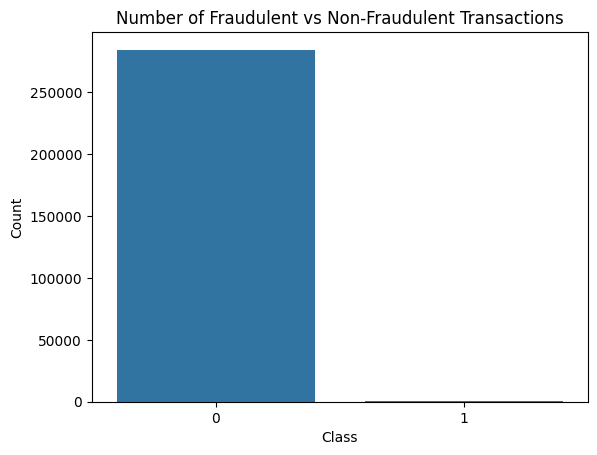

In [ ]:
#Barplot for the number of fraudulent and non-fraudulent transactions
sns.countplot(x='Class', data=creditcard_df)
plt.title('Number of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

            Class  Percentage
0  Non-Fraudulent    0.998273
1      Fraudulent    0.001727
--------------------------------------------------
Non-Fraudulent Share:
99.82725143693798
--------------------------------------------------
Fraudulent Share:
0.1727485630620034
--------------------------------------------------


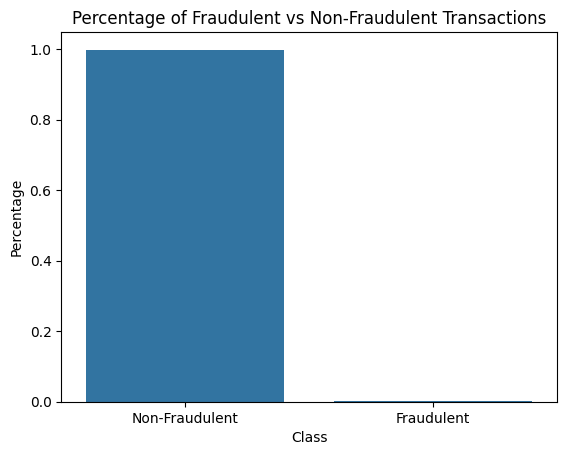

In [ ]:
#Barplot for the percentage of fraudulent and non-fraudulent transactions
fraud_percentage = {'Class':['Non-Fraudulent','Fraudulent'], 'Percentage':[creditcard_df['Class'].value_counts()[0]/len(creditcard_df), creditcard_df['Class'].value_counts()[1]/len(creditcard_df)]}
creditcard_df_fraud_percentage = pd.DataFrame(fraud_percentage)
non_fraud_percentage = creditcard_df_fraud_percentage.iloc[0,1] *100
fraud_percentage = creditcard_df_fraud_percentage.iloc[1,1] *100
print(creditcard_df_fraud_percentage)
print("-"*50)
print("Non-Fraudulent Share:")
print(non_fraud_percentage)
print("-"*50)
print("Fraudulent Share:")
print(fraud_percentage)
print("-"*50)

sns.barplot(x='Class', y='Percentage', data=creditcard_df_fraud_percentage)
plt.title('Percentage of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

In [ ]:
#Creating fraudulent dataframe
fraud_df = creditcard_df[creditcard_df['Class'] == 1]
print("Fraudulent Transactions:")
print(fraud_df.head())
#Creating non-fraudulent dataframe
print("-"*50)
print("Non-Fraudulent Transactions:")
non_fraud_df = creditcard_df[creditcard_df['Class'] == 0]
print(non_fraud_df.head())

Fraudulent Transactions:
        Time        V1        V2        V3        V4        V5        V6  \
541    406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623    472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920  4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
6108  6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329  7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   

            V7        V8        V9  ...       V21       V22       V23  \
541  -2.537387  1.391657 -2.770089  ...  0.517232 -0.035049 -0.465211   
623   0.325574 -0.067794 -0.270953  ...  0.661696  0.435477  1.375966   
4920  0.562320 -0.399147 -0.238253  ... -0.294166 -0.932391  0.172726   
6108 -3.496197 -0.248778 -0.247768  ...  0.573574  0.176968 -0.436207   
6329  1.713445 -0.496358 -1.282858  ... -0.379068 -0.704181 -0.656805   

           V24       V25       V26       V27       V28  Amount  Class  
541   0

In [ ]:
#Observing fraud and non-fraud dataframes
print("Shape of Fraud Transactions:")
print(fraud_df.shape)
print("-"*50)
print("Information of Fraud Transactions:")
print(fraud_df.info())
print("-"*50)
print("Description of Fraud Transactions:")
print(fraud_df.describe())
print("-"*50)

print("Shape of Non-Fraud Transactions:")
print(non_fraud_df.shape)
print("-"*50)
print("Information of Non-Fraud Transactions:")
print(non_fraud_df.info())
print("-"*50)
print("Description of Non-Fraud Transactions:")
print(non_fraud_df.describe())


Shape of Fraud Transactions:
(492, 31)
--------------------------------------------------
Information of Fraud Transactions:
<class 'pandas.core.frame.DataFrame'>
Index: 492 entries, 541 to 281674
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    492 non-null    float64
 1   V1      492 non-null    float64
 2   V2      492 non-null    float64
 3   V3      492 non-null    float64
 4   V4      492 non-null    float64
 5   V5      492 non-null    float64
 6   V6      492 non-null    float64
 7   V7      492 non-null    float64
 8   V8      492 non-null    float64
 9   V9      492 non-null    float64
 10  V10     492 non-null    float64
 11  V11     492 non-null    float64
 12  V12     492 non-null    float64
 13  V13     492 non-null    float64
 14  V14     492 non-null    float64
 15  V15     492 non-null    float64
 16  V16     492 non-null    float64
 17  V17     492 non-null    float64
 18  V18     492 non-null    f

**Observing the distribution of classes with Time**

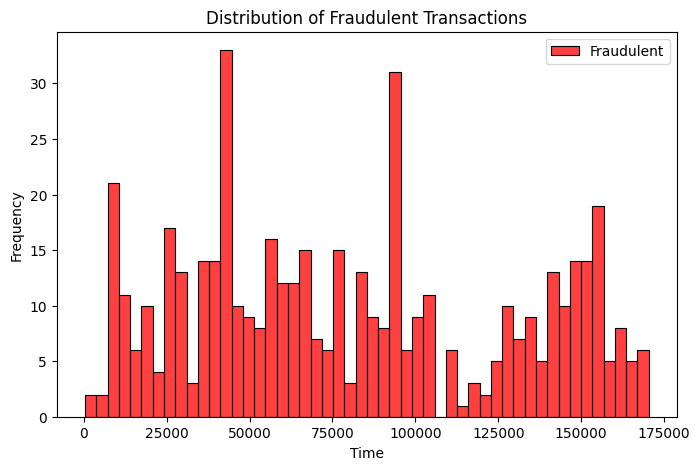

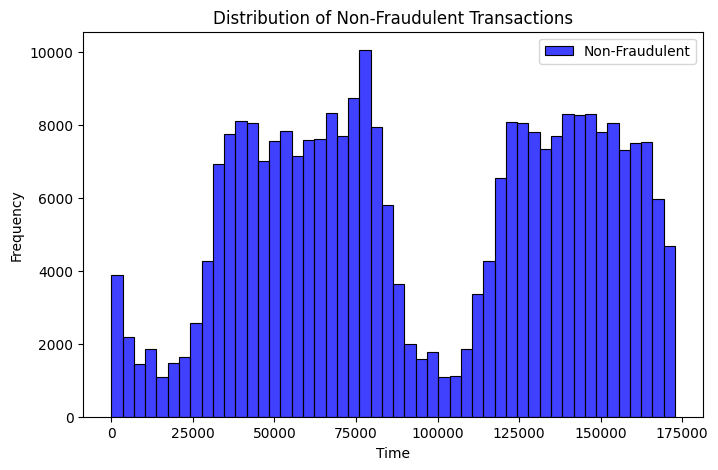

In [ ]:
#Distribution plot
#Distribution of fraudulent transactions
plt.figure(figsize=(8,5))
sns.histplot(fraud_df['Time'], bins=50, color='red', label='Fraudulent')
plt.legend()
plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

#Distribution of non-fraudulent transactions
plt.figure(figsize=(8,5))
sns.histplot(non_fraud_df['Time'], bins=50, color='blue', label='Non-Fraudulent')
plt.legend()
plt.title('Distribution of Non-Fraudulent Transactions')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()


In [ ]:
#HISTOGRAM
creditcard_df.hist(bins=50, figsize=(20, 15))
plt.show()

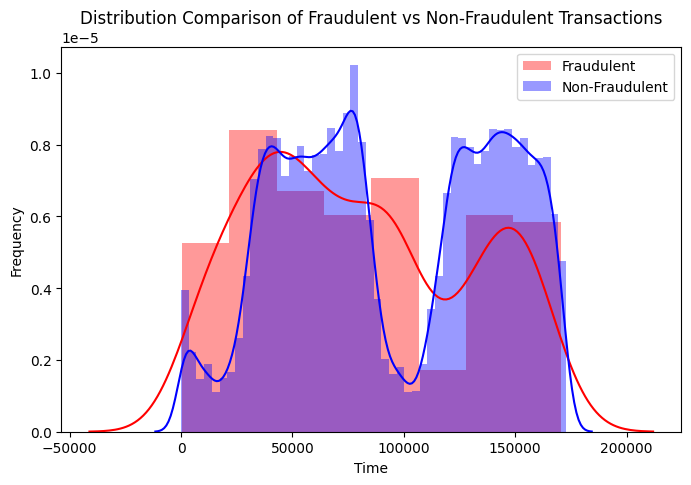

In [ ]:
#Distribution Comparison
plt.figure(figsize=(8,5))
ax = sns.distplot(fraud_df['Time'], color='red', label='Fraudulent')
ax = sns.distplot(non_fraud_df['Time'], color='blue', label='Non-Fraudulent')
ax.set_xlabel('Time')
ax.set_ylabel('Frequency')
ax.set_title('Distribution Comparison of Fraudulent vs Non-Fraudulent Transactions')
ax.legend()
plt.show()

**Observing the distribution of classes with Amount**

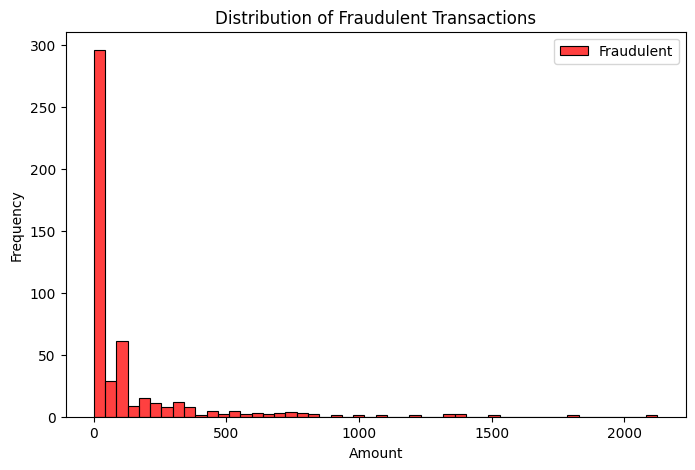

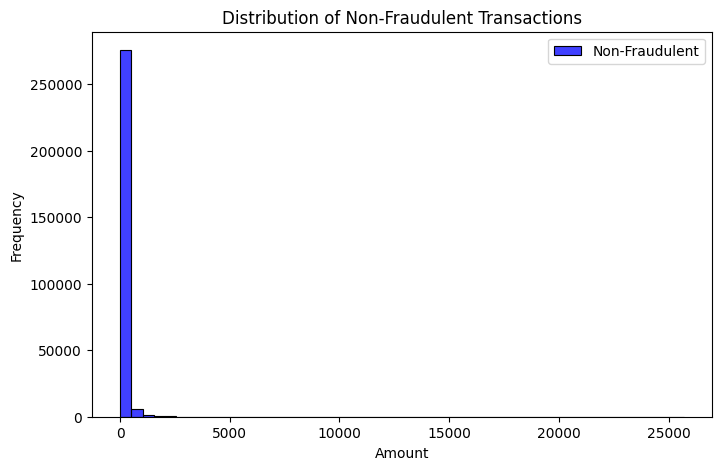

In [ ]:
#Distribution plot
#Distribution of fraudulent transactions
plt.figure(figsize=(8,5))
sns.histplot(fraud_df['Amount'], bins=50, color='red', label='Fraudulent')
plt.legend()
plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

#Distribution of non-fraudulent transactions
plt.figure(figsize=(8,5))
sns.histplot(non_fraud_df['Amount'], bins=50, color='blue', label='Non-Fraudulent')
plt.legend()
plt.title('Distribution of Non-Fraudulent Transactions')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()


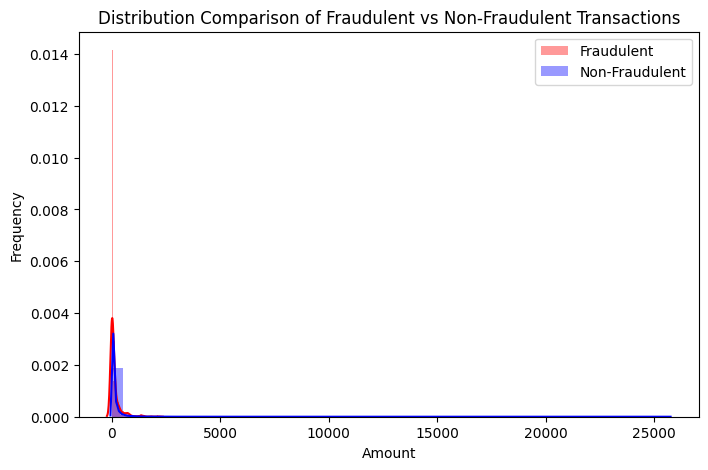

In [ ]:
#Distribution Comparison
plt.figure(figsize=(8,5))
ax = sns.distplot(fraud_df['Amount'], color='red', label='Fraudulent')
ax = sns.distplot(non_fraud_df['Amount'], color='blue', label='Non-Fraudulent')
ax.set_xlabel('Amount')
ax.set_ylabel('Frequency')
ax.set_title('Distribution Comparison of Fraudulent vs Non-Fraudulent Transactions')
ax.legend()
plt.show()


### **Transaction Amount Summary**

In [ ]:
#Calculate summary statistics for both groups
fraud_amount_summary = fraud_df['Amount'].describe()
non_fraud_amount_summary = non_fraud_df['Amount'].describe()

#Print the summary statistics
print("Fraudulent Transactions:")
print(fraud_amount_summary)
print("-"*50)
print("Non-Fraudulent Transactions:")
print(non_fraud_amount_summary)

Fraudulent Transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
--------------------------------------------------
Non-Fraudulent Transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


### **Transaction Time Summary**

In [ ]:
#Calculate summary statistics for both groups
fraud_time_summary = fraud_df['Time'].describe()
non_fraud_time_summary = non_fraud_df['Time'].describe()

#Print the summary statistics
print("Fraudulent Transactions:")
print(fraud_time_summary)
print("-"*50)
print("Non-Fraudulent Transactions:")
print(non_fraud_time_summary)

Fraudulent Transactions:
count       492.000000
mean      80746.806911
std       47835.365138
min         406.000000
25%       41241.500000
50%       75568.500000
75%      128483.000000
max      170348.000000
Name: Time, dtype: float64
--------------------------------------------------
Non-Fraudulent Transactions:
count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64


# **Feature Correlation**

In [ ]:
#Calculate the correlation matrix
correlation_matrix = creditcard_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
            Time            V1            V2            V3            V4  \
Time    1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1      0.117396  1.000000e+00  4.135835e-16 -1.227819e-15 -9.215150e-16   
V2     -0.010593  4.135835e-16  1.000000e+00  3.243764e-16 -1.121065e-15   
V3     -0.419618 -1.227819e-15  3.243764e-16  1.000000e+00  4.711293e-16   
V4     -0.105260 -9.215150e-16 -1.121065e-15  4.711293e-16  1.000000e+00   
V5      0.173072  1.812612e-17  5.157519e-16 -6.539009e-17 -1.719944e-15   
V6     -0.063016 -6.506567e-16  2.787346e-16  1.627627e-15 -7.491959e-16   
V7      0.084714 -1.005191e-15  2.055934e-16  4.895305e-16 -4.104503e-16   
V8     -0.036949 -2.433822e-16 -5.377041e-17 -1.268779e-15  5.697192e-16   
V9     -0.008660 -1.513678e-16  1.978488e-17  5.568367e-16  6.923247e-16   
V10     0.030617  7.388135e-17 -3.991394e-16  1.156587e-15  2.232685e-16   
V11    -0.247689  2.125498e-16  1.975426e-16  1.576830e-15  3.459380

In [ ]:
#Information of correlation matrix
print("Shape of Correlation Matrix:")
print(correlation_matrix.shape)
print("-"*50)
print("Correlation Matrix Head:")
print(correlation_matrix.head())
print("-"*50)
print("Correlation Matrix Tail:")
print(correlation_matrix.tail())
print("-"*50)
print("Correlation Matrix Info:")
print(correlation_matrix.info())
print("-"*50)
print("Correlation Matrix Description:")
print(correlation_matrix.describe())
print("-"*50)
print("Correlation Matrix Columns:")
print(correlation_matrix.columns)
print("-"*50)
print("Correlation Matrix Index:")
print(correlation_matrix.index)
print("-"*50)
print("Correlation Matrix Values:")
print(correlation_matrix.values)
print("-"*50)
print("Correlation Matrix Data Type:")
print(correlation_matrix.dtypes)
print("-"*50)
print("Correlation Matrix Null Values:")
print(correlation_matrix.isnull().sum())
print("-"*50)
print("Correlation Matrix Null Values Percentage:")
print(correlation_matrix.isnull().sum()/len(correlation_matrix)*100)


Shape of Correlation Matrix:
(31, 31)
--------------------------------------------------
Correlation Matrix Head:
          Time            V1            V2            V3            V4  \
Time  1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1    0.117396  1.000000e+00  4.135835e-16 -1.227819e-15 -9.215150e-16   
V2   -0.010593  4.135835e-16  1.000000e+00  3.243764e-16 -1.121065e-15   
V3   -0.419618 -1.227819e-15  3.243764e-16  1.000000e+00  4.711293e-16   
V4   -0.105260 -9.215150e-16 -1.121065e-15  4.711293e-16  1.000000e+00   

                V5            V6            V7            V8            V9  \
Time  1.730721e-01 -6.301647e-02  8.471437e-02 -3.694943e-02 -8.660434e-03   
V1    1.812612e-17 -6.506567e-16 -1.005191e-15 -2.433822e-16 -1.513678e-16   
V2    5.157519e-16  2.787346e-16  2.055934e-16 -5.377041e-17  1.978488e-17   
V3   -6.539009e-17  1.627627e-15  4.895305e-16 -1.268779e-15  5.568367e-16   
V4   -1.719944e-15 -7.491959e-16 -4.104503e-16  5.6

--------------------------------------------------
Correlation with Target Variable:
Time     -0.012323
V1       -0.101347
V2        0.091289
V3       -0.192961
V4        0.133447
V5       -0.094974
V6       -0.043643
V7       -0.187257
V8        0.019875
V9       -0.097733
V10      -0.216883
V11       0.154876
V12      -0.260593
V13      -0.004570
V14      -0.302544
V15      -0.004223
V16      -0.196539
V17      -0.326481
V18      -0.111485
V19       0.034783
V20       0.020090
V21       0.040413
V22       0.000805
V23      -0.002685
V24      -0.007221
V25       0.003308
V26       0.004455
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64
--------------------------------------------------
Sorted Correlation with Target Variable:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.0033

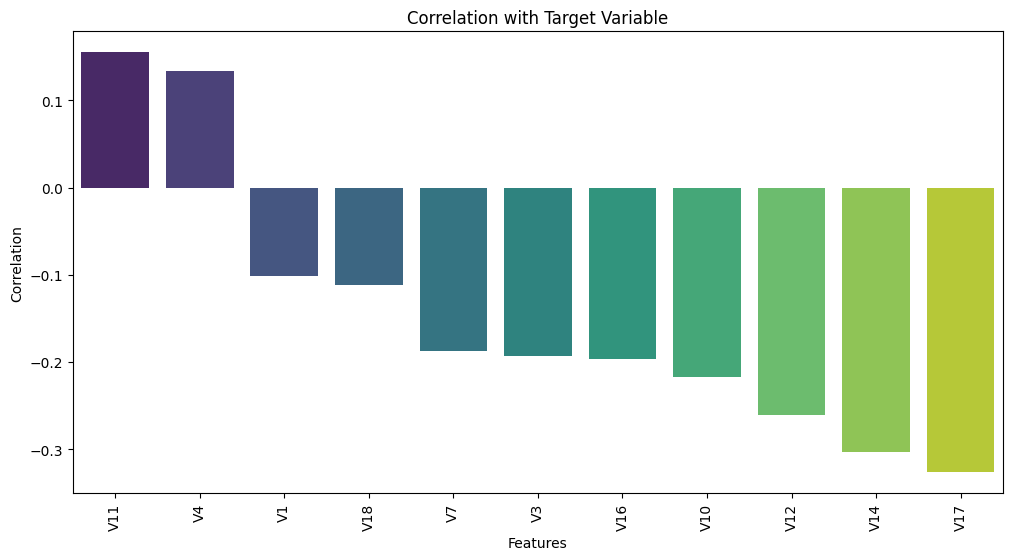

In [ ]:
#Filter the correlations of features with target variable ('Class')
correlation_with_target = correlation_matrix['Class'].drop('Class')
print("-"*50)
print("Correlation with Target Variable:")
print(correlation_with_target)

correlation_with_target = correlation_with_target.sort_values(ascending=False)
print("-"*50)
print("Sorted Correlation with Target Variable:")
print(correlation_with_target)

correlation_threshold = 0.1
high_correlation_features = correlation_with_target[abs(correlation_with_target) > correlation_threshold]
print("-"*50)
print("High Correlation Features:")
print(high_correlation_features)
print("-"*50)
print("Number of High Correlation Features:")
print(len(high_correlation_features))
print("-"*50)
print("High Correlation Features:")
print(high_correlation_features.index)


#Graph
plt.figure(figsize=(12, 6))
sns.barplot(x=high_correlation_features.index, y=high_correlation_features.values, palette='viridis')
plt.title('Correlation with Target Variable')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.show()


## **Transaction Amount vs Time**

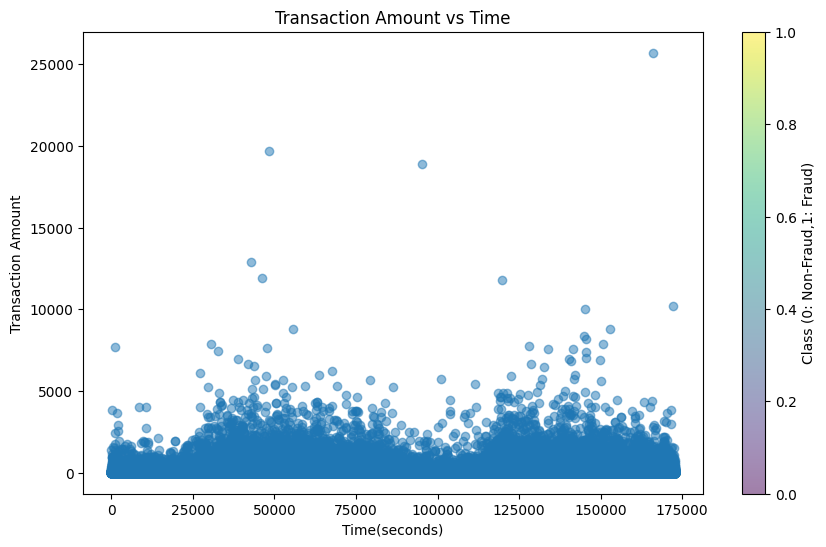

In [ ]:
#Scatter plot to examine the relationship between transaction amount vs time
plt.figure(figsize=(10, 6))
plt.scatter(creditcard_df['Time'], creditcard_df['Amount'], cmap='coolwarm', alpha=0.5)
plt.title('Transaction Amount vs Time')
plt.xlabel('Time(seconds)')
plt.ylabel('Transaction Amount')
plt.colorbar(label='Class (0: Non-Fraud,1: Fraud)')
plt.show()

## **Visualize Heatmap for Correlation Matrix**

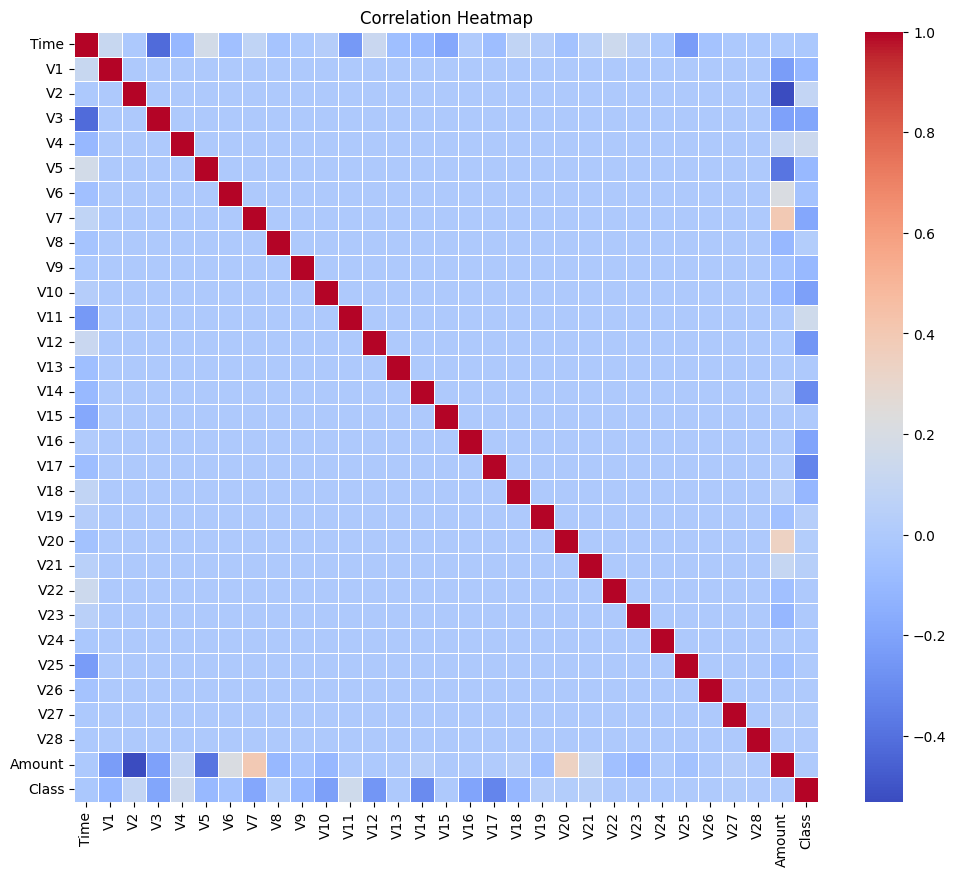

In [ ]:
#Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## **FEATURE AND TARGET VARIABLE**

**Creating** **X** **and** **y**

In [ ]:
#Putting feature variables into X
X = creditcard_df.drop('Class', axis=1)
#Putting target variable to y
y = creditcard_df['Class']

print("X and y created successfully!")
print("-"*50)
print("X head:")
print(X.head())
print("-"*50)
print("y head:")
print(y.head())


X and y created successfully!
--------------------------------------------------
X head:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  .

**Displaying X and y**

In [ ]:
#Displaying features and target variable
print("Features:")
print(X.head())
print("-"*50)
print("Target Variable:")
print(y.head())

Features:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26 

In [ ]:
#Shape of X and y
print("Shape of X:")
print(X.shape)
print("-"*50)
print("Shape of y:")
print(y.shape)

Shape of X:
(284807, 30)
--------------------------------------------------
Shape of y:
(284807,)


# **TRAIN** **-** **TEST** **SPLITTING**

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

print("Train-Test Splitting performed successfully!")
print("-"*50)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("-"*50)
print("X_train head:")
print(X_train.head())
print("-"*50)
print("X_test head:")
print(X_test.head())
X_train = X_train.copy()
X_test = X_test.copy()
y_train = y_train.copy()
y_test = y_test.copy()


Train-Test Splitting performed successfully!
--------------------------------------------------
Shape of X_train: (227845, 30)
Shape of X_test: (56962, 30)
Shape of y_train: (227845,)
Shape of y_test: (56962,)
--------------------------------------------------
X_train head:
            Time        V1        V2        V3        V4        V5        V6  \
265518  161919.0  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  124477.0  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664    41191.0 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  132624.0  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325    59359.0 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22  \
265518 -1.479661  1.139880  1.406819  ... -0.134435  0.076197  0.297537   
180305 -0.002192  0.674782  0.045826  ... -0.227279  0.038628  0.228197   
42664  -2.212603 -5

# **FEATURE SCALING**

In [ ]:
#Initiate the scaler
scaler = StandardScaler()

In [ ]:
#Fit the data into scaler and transform

# Initiate the scaler
scaler = StandardScaler()

# Columns to scale
cols_to_scale = ["Amount", "Time"]

# Fit on training data for the specified columns and transform
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform test data using the *same* fitted scaler
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Display heads to check the scaled data
print("X_train head after scaling Amount and Time:")
print(X_train.head())
print("\nX_test head after scaling Amount and Time:")
print(X_test.head())

X_train head after scaling Amount and Time:
            Time        V1        V2        V3        V4        V5        V6  \
265518  1.411588  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  0.623141  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664  -1.130680 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  0.794699  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325  -0.748102 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22  \
265518 -1.479661  1.139880  1.406819  ... -0.134435  0.076197  0.297537   
180305 -0.002192  0.674782  0.045826  ... -0.227279  0.038628  0.228197   
42664  -2.212603 -5.037523  0.000772  ...  1.280856 -2.798352  0.109526   
198723 -1.427984  0.010010 -1.118447  ... -0.490642 -0.139670  0.077013   
82325   0.504347 -0.113817 -0.044782  ... -0.275297 -0.243245 -0.173298   

             V23       V

### **Checking the Skewness**

In [ ]:
X_train.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [ ]:
X_train.skew()

,0
Time,-0.037394
V1,-3.306334
V2,-4.779484
V3,-2.247962
V4,0.687574
V5,-2.786851
V6,1.937381
V7,3.152665
V8,-8.639485
V9,0.541869


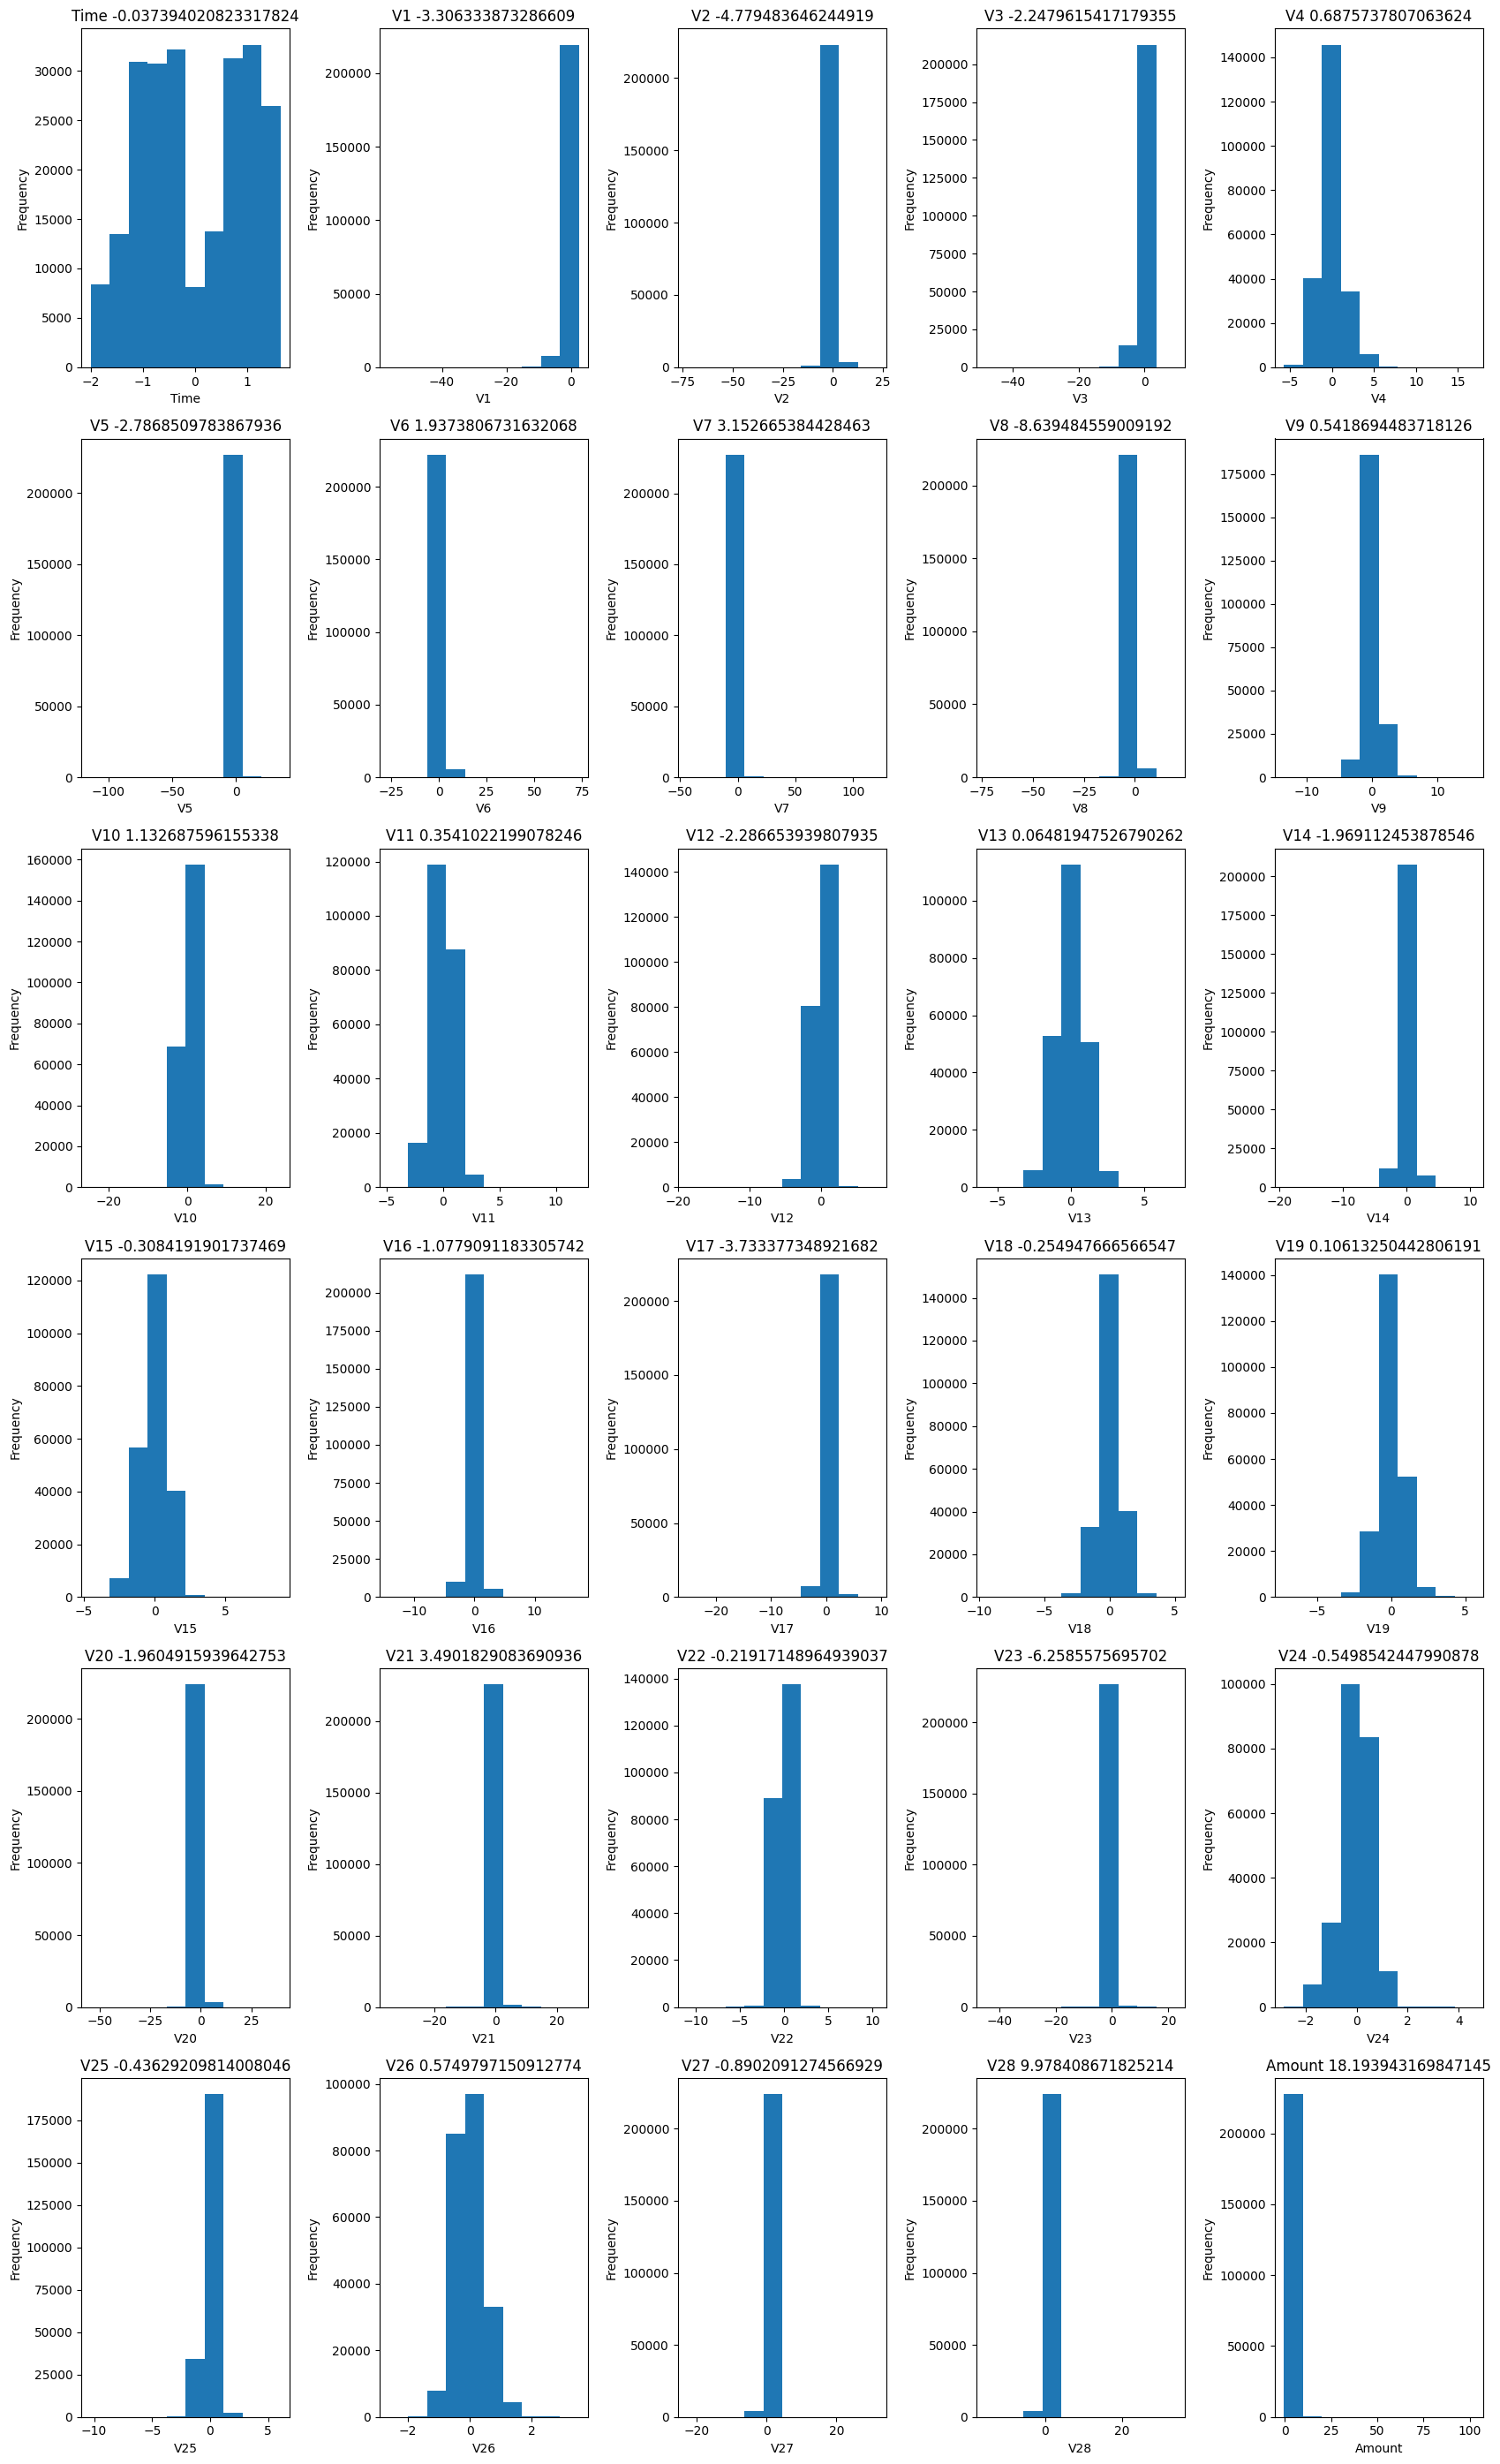

In [ ]:
#Plotting the distribution of the variables (skewness) of all the columns
k=0
plt.figure(figsize=(17,28))
for col in X_train.columns:
    k+=1
    plt.subplot(6,5,k)
    plt.hist(X_train[col])
    plt.title(col+" "+str(X_train[col].skew()))
    plt.tight_layout()
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.show()


### **Mitigate Skewness with PowerTransformer**

In [ ]:
#Importing PowerTransformer
from sklearn.preprocessing import PowerTransformer

In [ ]:
#Initiate the PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=True, copy=False)

In [ ]:
#Fit and transform the PT on training data
X_train[cols_to_scale] = pt.fit_transform(X_train[cols_to_scale])

#Transform the test set
X_test[cols_to_scale] = pt.transform(X_test[cols_to_scale])

print("Transformed Successfully!")
print("\nX_train head after scaling Amount and Time:")
print(X_train.head())
print("\nX_test head after scaling Amount and Time:")
print(X_test.head())

Transformed Successfully!

X_train head after scaling Amount and Time:
            Time        V1        V2        V3        V4        V5        V6  \
265518  1.416557  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  0.620274  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664  -1.129230 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  0.793146  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325  -0.750172 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22  \
265518 -1.479661  1.139880  1.406819  ... -0.134435  0.076197  0.297537   
180305 -0.002192  0.674782  0.045826  ... -0.227279  0.038628  0.228197   
42664  -2.212603 -5.037523  0.000772  ...  1.280856 -2.798352  0.109526   
198723 -1.427984  0.010010 -1.118447  ... -0.490642 -0.139670  0.077013   
82325   0.504347 -0.113817 -0.044782  ... -0.275297 -0.243245 -0.173298  

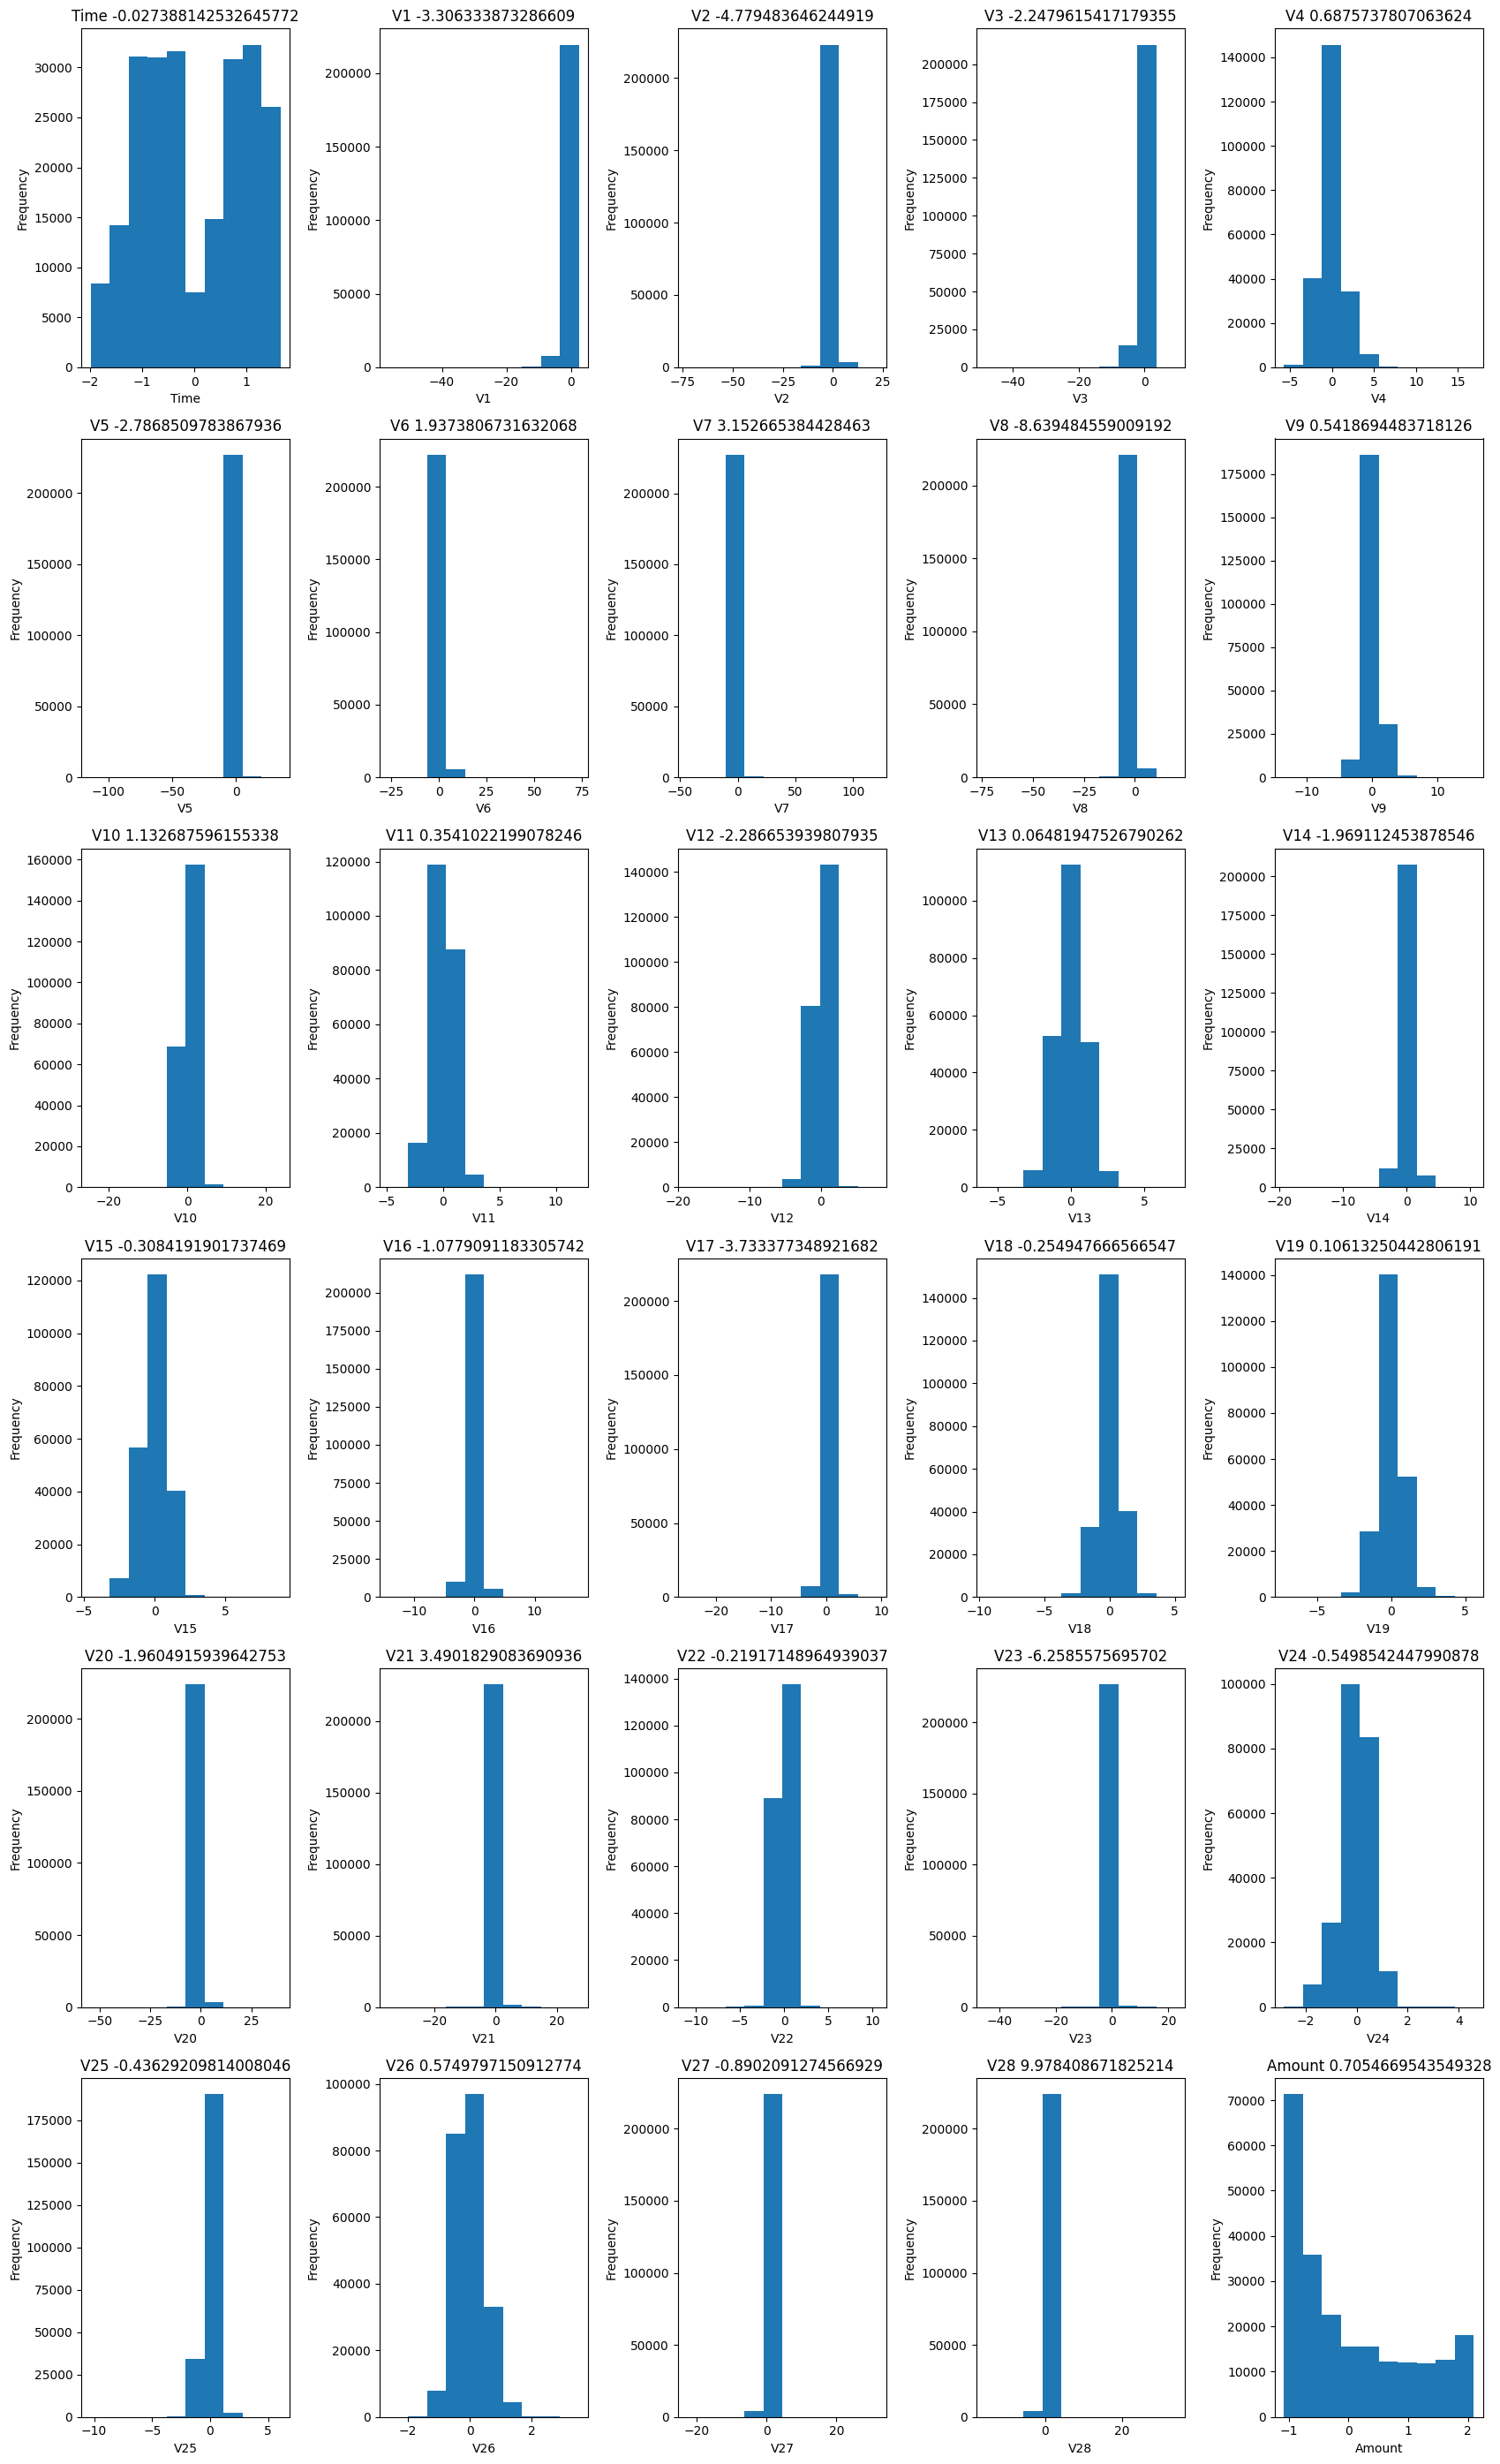

In [ ]:
#Plotting the distribution of the variables (skewness) of all the columns
k=0
plt.figure(figsize=(17,28))
for col in X_train.columns:
    k+=1
    plt.subplot(6,5,k)
    plt.hist(X_train[col])
    plt.title(col+" "+str(X_train[col].skew()))
    plt.tight_layout()
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.show()

# **MODELS: Development & Training**

**Model1: LOGISTIC REGRESSION**

In [ ]:
#Model1
model1 = LogisticRegression(random_state=42)
lr = model1

#Train the model on training data
lr.fit(X_train, y_train)
print("Model1 trained successfully!")

#Train the model on testing data
y_pred_lr = lr.predict(X_test)
print("Model1 predicted successfully!")

Model1 trained successfully!
Model1 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_lr:")
print(y_pred_lr)

y_pred_lr:
[0 0 0 ... 0 0 0]


**Model2: DECISION TREE**

In [ ]:
#Model2
model2 = DecisionTreeClassifier(random_state=42)
dt = model2

#Train the model on training data
dt.fit(X_train, y_train)
print("Model2 trained successfully!")

#Train the model on testing data
y_pred_dt = dt.predict(X_test)
print("Model2 predicted successfully!")

Model2 trained successfully!
Model2 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_dt:")
print(y_pred_dt)

y_pred_dt:
[0 0 0 ... 0 0 0]


 **Model3: RANDOM FOREST**

In [ ]:
#Model3
model3 = RandomForestClassifier(random_state=42)
rf = model3

#Train the model on training data
rf.fit(X_train, y_train)
print("Model3 trained successfully!")

#Train the model on testing data
y_pred_rf = rf.predict(X_test)
print("Model3 predicted successfully!")

Model3 trained successfully!
Model3 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_rf:")
print(y_pred_rf)

y_pred_rf:
[0 0 0 ... 0 0 0]


**Model4: K-NEAREST NEIGHBORS (KNN)**

In [ ]:
#Model4
model4 = KNeighborsClassifier(n_neighbors=5)
knn = model4

#Train the model on training data
knn.fit(X_train, y_train)
print("Model4 trained successfully!")

#Train the model on testing data
y_pred_knn = knn.predict(X_test)
print("Model4 predicted successfully!")

Model4 trained successfully!
Model4 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_knn:")
print(y_pred_knn)

y_pred_knn:
[0 0 0 ... 0 0 0]


**Model5: SUPPORT VECTOR MACHINE (SVM)**

In [ ]:
#Model5
model5 = SVC()
svm = model5

#Train the model on training data
svm.fit(X_train, y_train)
print("Model5 trained successfully!")

#Train the model on testing data
y_pred_svm = svm.predict(X_test)
print("Model5 predicted successfully!")

Model5 trained successfully!
Model5 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_svm:")
print(y_pred_svm)

y_pred_svm:
[0 0 0 ... 0 0 0]


**Model6: GAUSSIAN NAIVE BIAS**

In [ ]:
#Model6
model6 = GaussianNB()
gnb = model6

#Train the model on training data
gnb.fit(X_train, y_train)
print("Model6 trained successfully!")

#Train the model on testing data
y_pred_gnb = gnb.predict(X_test)
print("Model6 predicted successfully!")

Model6 trained successfully!
Model6 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_gnb:")
print(y_pred_gnb)

y_pred_gnb:
[0 0 1 ... 0 0 0]


**Model7: GRADIENT BOOSTING**

In [ ]:
#Model7
model7 = GradientBoostingClassifier()
gbc = model7

#Train the model on training data
gbc.fit(X_train, y_train)
print("Model7 trained successfully!")

#Train the model on testing data
y_pred_gbc = gbc.predict(X_test)
print("Model7 predicted successfully!")

Model7 trained successfully!
Model7 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_gbc:")
print(y_pred_gbc)

y_pred_gbc:
[0 0 0 ... 0 0 0]


**Model8: XGBOOST**

In [ ]:
#Model8
model8 = XGBClassifier(random_state=42)
xgb = model8

#Train the model on training data
xgb.fit(X_train, y_train)
print("Model8 trained successfully!")

#Train the model on testing data
y_pred_xgb = xgb.predict(X_test)
print("Model8 predicted successfully!")

Model8 trained successfully!
Model8 predicted successfully!


In [ ]:
#Displaying values
print("y_pred_xgb:")
print(y_pred_xgb)

y_pred_xgb:
[0 0 0 ... 0 0 0]


# **MODELS: Evaluation**

In [ ]:
#Model Evaluation
def evaluate_model(model, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    classification_rep = classification_report(y_true, y_pred)
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc,
        'Confusion Matrix': conf_matrix,
        'Classification Report': classification_rep
    }

lr_metrics = evaluate_model(lr, y_test, y_pred_lr)
dt_metrics = evaluate_model(dt, y_test, y_pred_dt)
rf_metrics = evaluate_model(rf, y_test, y_pred_rf)
knn_metrics = evaluate_model(knn, y_test, y_pred_knn)
svm_metrics = evaluate_model(svm, y_test, y_pred_svm)
gnb_metrics = evaluate_model(gnb, y_test, y_pred_gnb)
gbc_metrics = evaluate_model(gbc, y_test, y_pred_gbc)
xgb_metrics = evaluate_model(xgb, y_test, y_pred_xgb)

print("Model Evaluation Results:")
print("-"*50)
print("Logistic Regression:")
print(lr_metrics)
print("-"*50)
print("Decision Tree:")
print(dt_metrics)
print("-"*50)
print("Random Forest:")
print(rf_metrics)
print("-"*50)
print("K-Nearest Neighbors (KNN):")
print(knn_metrics)
print("-"*50)
print("Support Vector Machine (SVM):")
print(svm_metrics)
print("-"*50)
print("Gaussian Naive Bayes:")
print(gnb_metrics)
print("-"*50)
print("Gradient Boosting:")
print(gbc_metrics)
print("-"*50)
print("XGBoost:")
print(xgb_metrics)
print("-"*50)

Model Evaluation Results:
--------------------------------------------------
Logistic Regression:
{'Accuracy': 0.9991748885221726, 'Precision': 0.8311688311688312, 'Recall': 0.6530612244897959, 'F1 Score': 0.7314285714285714, 'ROC AUC': np.float64(0.8264163044227257), 'Confusion Matrix': array([[56851,    13],
       [   34,    64]]), 'Classification Report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00     56864\n           1       0.83      0.65      0.73        98\n\n    accuracy                           1.00     56962\n   macro avg       0.92      0.83      0.87     56962\nweighted avg       1.00      1.00      1.00     56962\n'}
--------------------------------------------------
Decision Tree:
{'Accuracy': 0.9991397773954567, 'Precision': 0.7525773195876289, 'Recall': 0.7448979591836735, 'F1 Score': 0.7487179487179487, 'ROC AUC': np.float64(0.8722379497662881), 'Confusion Matrix': array([[56840,    24],
       [   25,    73

**DISPLAY** **METRICS**

In [ ]:
#Metrics Display
print("Metrics Evaluation Results:")
print("-"*50)

print("Logistic Regression:")
print("Accuracy:", lr_metrics['Accuracy'])
print("Precision:", lr_metrics['Precision'])
print("Recall:", lr_metrics['Recall'])
print("F1 Score:", lr_metrics['F1 Score'])
print("ROC AUC:", lr_metrics['ROC AUC'])
print("Confusion Matrix:\n", lr_metrics['Confusion Matrix'])
print("Classification Report:\n", lr_metrics['Classification Report'])
print("-"*50)

print("Decision Tree:")
print("Accuracy:", dt_metrics['Accuracy'])
print("Precision:", dt_metrics['Precision'])
print("Recall:", dt_metrics['Recall'])
print("F1 Score:", dt_metrics['F1 Score'])
print("ROC AUC:", dt_metrics['ROC AUC'])
print("Confusion Matrix:\n", dt_metrics['Confusion Matrix'])
print("Classification Report:\n", dt_metrics['Classification Report'])
print("-"*50)

print("Random Forest:")
print("Accuracy:", rf_metrics['Accuracy'])
print("Precision:", rf_metrics['Precision'])
print("Recall:", rf_metrics['Recall'])
print("F1 Score:", rf_metrics['F1 Score'])
print("ROC AUC:", rf_metrics['ROC AUC'])
print("Confusion Matrix:\n", rf_metrics['Confusion Matrix'])
print("Classification Report:\n", rf_metrics['Classification Report'])
print("-"*50)

print("K-Nearest Neighbors (KNN):")
print("Accuracy:", knn_metrics['Accuracy'])
print("Precision:", knn_metrics['Precision'])
print("Recall:", knn_metrics['Recall'])
print("F1 Score:", knn_metrics['F1 Score'])
print("ROC AUC:", knn_metrics['ROC AUC'])
print("Confusion Matrix:\n", knn_metrics['Confusion Matrix'])
print("Classification Report:\n", knn_metrics['Classification Report'])
print("-"*50)

print("Support Vector Machine (SVM):")
print("Accuracy:", svm_metrics['Accuracy'])
print("Precision:", svm_metrics['Precision'])
print("Recall:", svm_metrics['Recall'])
print("F1 Score:", svm_metrics['F1 Score'])
print("ROC AUC:", svm_metrics['ROC AUC'])
print("Confusion Matrix:\n", svm_metrics['Confusion Matrix'])
print("Classification Report:\n", svm_metrics['Classification Report'])
print("-"*50)

print("Gaussian Naive Bayes:")
print("Accuracy:", gnb_metrics['Accuracy'])
print("Precision:", gnb_metrics['Precision'])
print("Recall:", gnb_metrics['Recall'])
print("F1 Score:", gnb_metrics['F1 Score'])
print("ROC AUC:", gnb_metrics['ROC AUC'])
print("Confusion Matrix:\n", gnb_metrics['Confusion Matrix'])
print("Classification Report:\n", gnb_metrics['Classification Report'])
print("-"*50)

print("Gradient Boosting:")
print("Accuracy:", gbc_metrics['Accuracy'])
print("Precision:", gbc_metrics['Precision'])
print("Recall:", gbc_metrics['Recall'])
print("F1 Score:", gbc_metrics['F1 Score'])
print("ROC AUC:", gbc_metrics['ROC AUC'])
print("Confusion Matrix:\n", gbc_metrics['Confusion Matrix'])
print("Classification Report:\n", gbc_metrics['Classification Report'])
print("-"*50)

print("XGBoost:")
print("Accuracy:", xgb_metrics['Accuracy'])
print("Precision:", xgb_metrics['Precision'])
print("Recall:", xgb_metrics['Recall'])
print("F1 Score:", xgb_metrics['F1 Score'])
print("ROC AUC:", xgb_metrics['ROC AUC'])
print("Confusion Matrix:\n", xgb_metrics['Confusion Matrix'])
print("Classification Report:\n", xgb_metrics['Classification Report'])
print("-"*50)

print("Metrics Evaluated Successfully!")

Metrics Evaluation Results:
--------------------------------------------------
Logistic Regression:
Accuracy: 0.9991748885221726
Precision: 0.8311688311688312
Recall: 0.6530612244897959
F1 Score: 0.7314285714285714
ROC AUC: 0.8264163044227257
Confusion Matrix:
 [[56851    13]
 [   34    64]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

--------------------------------------------------
Decision Tree:
Accuracy: 0.9991397773954567
Precision: 0.7525773195876289
Recall: 0.7448979591836735
F1 Score: 0.7487179487179487
ROC AUC: 0.8722379497662881
Confusion Matrix:
 [[56840    24]
 [   25    73]]
Classification Report:
               precision    recall  f1-score   support

           0      

**MODEL COMPARISON**

In [ ]:
#Model Comparison
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'K-Nearest Neighbors',
        'Support Vector Machine',
        'Gaussian Naive Bayes',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        lr_metrics['Accuracy'],
        dt_metrics['Accuracy'],
        rf_metrics['Accuracy'],
        knn_metrics['Accuracy'],
        svm_metrics['Accuracy'],
        gnb_metrics['Accuracy'],
        gbc_metrics['Accuracy'],
        xgb_metrics['Accuracy']
    ],
    'Precision': [
        lr_metrics['Precision'],
        dt_metrics['Precision'],
        rf_metrics['Precision'],
        knn_metrics['Precision'],
        svm_metrics['Precision'],
        gnb_metrics['Precision'],
        gbc_metrics['Precision'],
        xgb_metrics['Precision']
    ],
    'Recall': [
        lr_metrics['Recall'],
        dt_metrics['Recall'],
        rf_metrics['Recall'],
        knn_metrics['Recall'],
        svm_metrics['Recall'],
        gnb_metrics['Recall'],
        gbc_metrics['Recall'],
        xgb_metrics['Recall']
    ],
    'F1 Score': [
        lr_metrics['F1 Score'],
        dt_metrics['F1 Score'],
        rf_metrics['F1 Score'],
        knn_metrics['F1 Score'],
        svm_metrics['F1 Score'],
        gnb_metrics['F1 Score'],
        gbc_metrics['F1 Score'],
        xgb_metrics['F1 Score']
    ],
    'ROC AUC': [
        lr_metrics['ROC AUC'],
        dt_metrics['ROC AUC'],
        rf_metrics['ROC AUC'],
        knn_metrics['ROC AUC'],
        svm_metrics['ROC AUC'],
        gnb_metrics['ROC AUC'],
        gbc_metrics['ROC AUC'],
        xgb_metrics['ROC AUC']
    ],
    'Confusion Matrix': [
        lr_metrics['Confusion Matrix'],
        dt_metrics['Confusion Matrix'],
        rf_metrics['Confusion Matrix'],
        knn_metrics['Confusion Matrix'],
        svm_metrics['Confusion Matrix'],
        gnb_metrics['Confusion Matrix'],
        gbc_metrics['Confusion Matrix'],
        xgb_metrics['Confusion Matrix']
    ],
    'Classification Report': [
        lr_metrics['Classification Report'],
        dt_metrics['Classification Report'],
        rf_metrics['Classification Report'],
        knn_metrics['Classification Report'],
        svm_metrics['Classification Report'],
        gnb_metrics['Classification Report'],
        gbc_metrics['Classification Report'],
        xgb_metrics['Classification Report']
    ]
})

print("Model Comparison:")
print(comparison)

Model Comparison:
                    Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0     Logistic Regression  0.999175   0.831169  0.653061  0.731429  0.826416   
1           Decision Tree  0.999140   0.752577  0.744898  0.748718  0.872238   
2           Random Forest  0.999596   0.941176  0.816327  0.874317  0.908119   
3     K-Nearest Neighbors  0.999508   0.916667  0.785714  0.846154  0.892796   
4  Support Vector Machine  0.999421   0.957746  0.693878  0.804734  0.846912   
5    Gaussian Naive Bayes  0.976616   0.059286  0.846939  0.110814  0.911889   
6       Gradient Boosting  0.998315   0.529412  0.183673  0.272727  0.591696   
7                 XGBoost  0.999491   0.896552  0.795918  0.843243  0.897880   

            Confusion Matrix  \
0    [[56851, 13], [34, 64]]   
1    [[56840, 24], [25, 73]]   
2     [[56859, 5], [18, 80]]   
3     [[56857, 7], [21, 77]]   
4     [[56861, 3], [30, 68]]   
5  [[55547, 1317], [15, 83]]   
6    [[56848, 16], [80, 18]]   
7    

## **BEST MODEL**

In [ ]:
#Best Model
best_model = comparison.loc[
    comparison['Accuracy'].idxmax(),
    'Model'
]

print("Best Performing Model:")
print(best_model)


Best Performing Model:
Random Forest


# **STRATIFIED K-FOLD CROSS-VALIDATION**

In [ ]:
#Stratified K-Fold Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_full_scaled = scaler.transform(X)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = cross_validate(
    rf,
    X_full_scaled,
    y,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

print("Stratified K-Fold Cross-Validation Results:")
print("-"*50)
print("Training Metrics:")
print("Accuracy:", results['train_accuracy'].mean())
print("Precision:", results['train_precision'].mean())
print("Recall:", results['train_recall'].mean())
print("F1 Score:", results['train_f1'].mean())
print("ROC AUC:", results['train_roc_auc'].mean())
print("-"*50)
print("Testing Metrics:")
print("Accuracy:", results['test_accuracy'].mean())
print("Precision:", results['test_precision'].mean())
print("Recall:", results['test_recall'].mean())
print("F1 Score:", results['test_f1'].mean())
print("ROC AUC:", results['test_roc_auc'].mean())
print("-"*50)

print("Cross-Validation Metrics Evaluated Successfully!")

Stratified K-Fold Cross-Validation Results:
--------------------------------------------------
Training Metrics:
Accuracy: 0.9999973666423813
Precision: 1.0
Recall: 0.9984771573604061
F1 Score: 0.999235668789809
ROC AUC: 1.0
--------------------------------------------------
Testing Metrics:
Accuracy: 0.9995540841292986
Precision: 0.9486745314075071
Recall: 0.7845804988662131
F1 Score: 0.8587705244393853
ROC AUC: 0.9465942927710685
--------------------------------------------------
Cross-Validation Metrics Evaluated Successfully!


# **HYPERPARAMETER** **TUNING**

In [ ]:
#Hyperparameter Tuning for Random Forest using Grid Search
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Hyperparameters for Random Forest:")
print(best_params)
print("Best Model for Random Forest:")
print(best_model)
print("Best Score for Random Forest:")
print(best_score)

y_pred_rf_tuned = best_model.predict(X_test)
rf_tuned_metrics = evaluate_model(best_model, y_test, y_pred_rf_tuned)
print("Model Evaluation Results:")
print("-"*50)
print("Random Forest (Tuned):")
print(rf_tuned_metrics)
print("-"*50)
print("Metrics Evaluated Successfully!")

print("Hyperparameter Tuning for Random Forest Completed!")

In [ ]:
#Hyperparameter Tuning for Random Forest using Randomized Search
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=2,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_
print("Best Hyperparameters for Random Forest:")
print(best_params)
print("Best Model for Random Forest:")
print(best_model)
print("Best Score for Random Forest:")
print(best_score)

y_pred_rf_tuned = best_model.predict(X_test)
rf_tuned_metrics = evaluate_model(best_model, y_test, y_pred_rf_tuned)
print("Model Evaluation Results:")
print("-"*50)
print("Random Forest (Tuned):")
print(rf_tuned_metrics)
print("-"*50)
print("Metrics Evaluated Successfully!")

print("Hyperparameter Tuning for Random Forest Completed!")

Best Hyperparameters for Random Forest:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best Model for Random Forest:
RandomForestClassifier(max_depth=20, max_features='log2', min_samples_split=5,
                       n_estimators=200, random_state=42)
Best Score for Random Forest:
0.9994733262032329
Model Evaluation Results:
--------------------------------------------------
Random Forest (Tuned):
{'Accuracy': 0.9995962220427653, 'Precision': 0.9411764705882353, 'Recall': 0.8163265306122449, 'F1 Score': 0.8743169398907104, 'ROC AUC': np.float64(0.9081193007591333), 'Confusion Matrix': array([[56859,     5],
       [   18,    80]]), 'Classification Report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00     56864\n           1       0.94      0.82      0.87        98\n\n    accuracy                           1.00     56962\n   macro avg       0.97      0.91      0.94  

# **LEARNING CURVE**

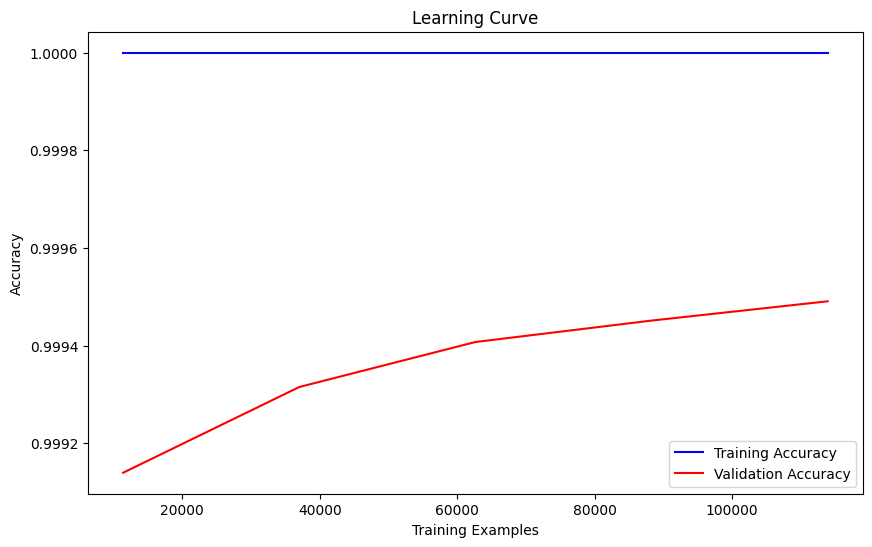

In [ ]:
#Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue')
plt.plot(train_sizes, test_mean, label='Validation Accuracy', color='red')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

# **CONFUSION** **MATRIX**

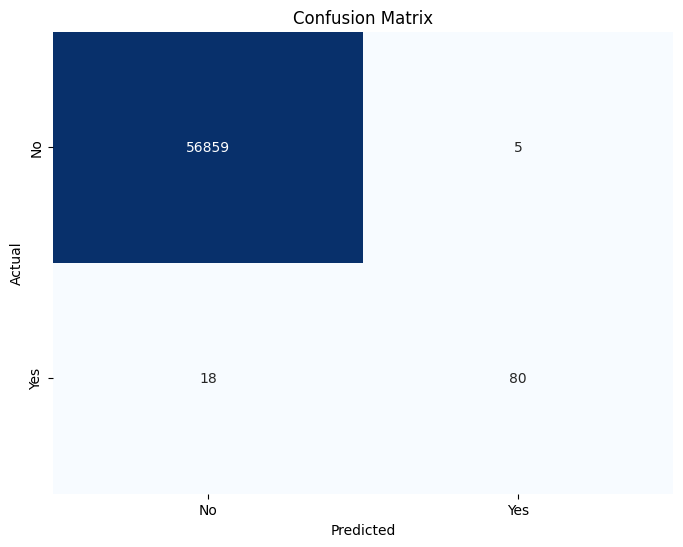

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# **ROC CURVE**

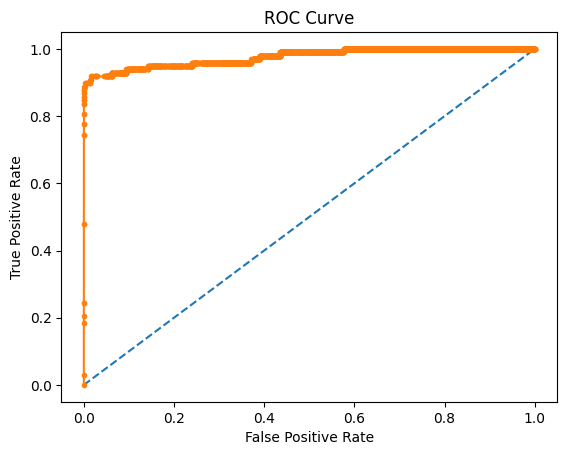

In [ ]:
#ROC Curve
prob = best_model.predict_proba(X_test)
prob = prob[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, prob)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# **FEATURE** **IMPORTANCE**

Feature Importance:
        Importance
V17       0.157454
V12       0.131822
V14       0.121323
V16       0.081678
V11       0.060911
V10       0.059605
V9        0.048232
V18       0.040133
V4        0.036462
V7        0.025453
V3        0.021886
V26       0.016184
V2        0.015321
V21       0.014847
V20       0.013516
V6        0.013149
V1        0.013112
V8        0.012673
V19       0.012084
V5        0.012008
V15       0.011033
Amount    0.010629
V13       0.010483
Time      0.010145
V28       0.009595
V27       0.009446
V22       0.009061
V25       0.007451
V23       0.007211
V24       0.007092
--------------------------------------------------
Feature Importance Evaluated Successfully!
Feature Importance Plot:


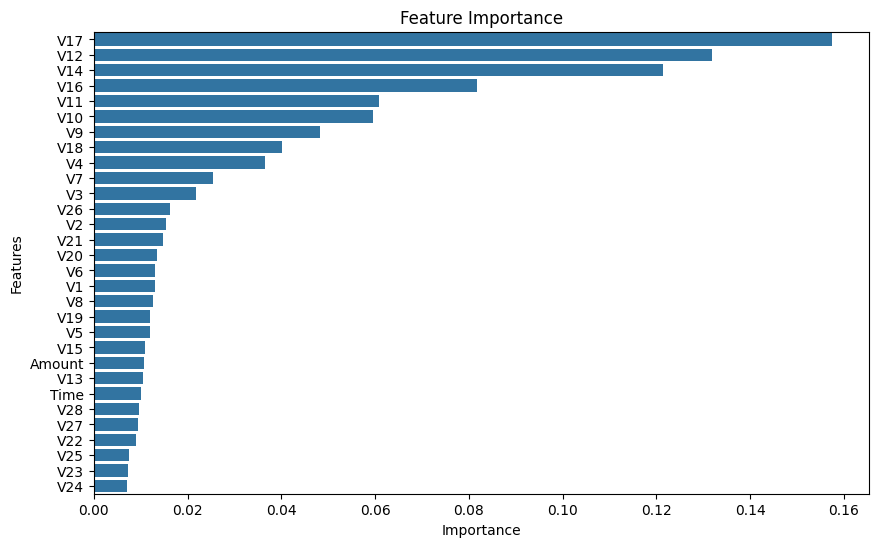


Most Important Features:
     Importance
V17    0.157454
V12    0.131822
V14    0.121323
V16    0.081678
V11    0.060911
V10    0.059605
V9     0.048232
V18    0.040133
V4     0.036462
V7     0.025453

Least Important Features:
        Importance
V15       0.011033
Amount    0.010629
V13       0.010483
Time      0.010145
V28       0.009595
V27       0.009446
V22       0.009061
V25       0.007451
V23       0.007211
V24       0.007092

Most Influential Feature:
Importance    V17
dtype: object

Least Influential Feature:
Importance    V24
dtype: object


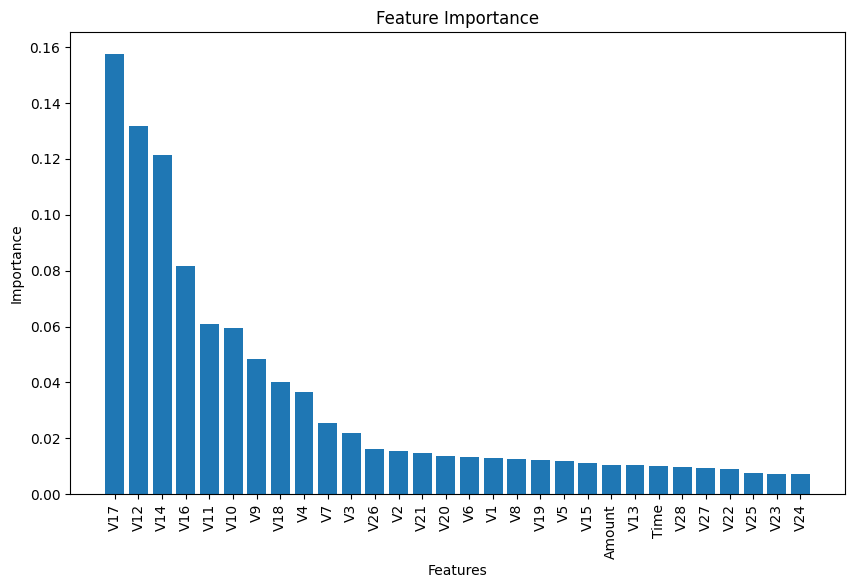

In [ ]:
#Feature Importance
importance = pd.DataFrame(
    best_model.feature_importances_,
    index=X.columns,
    columns=['Importance']
)
importance = importance.sort_values(by='Importance', ascending=False)
print("Feature Importance:")
print(importance)
print("-"*50)
print("Feature Importance Evaluated Successfully!")

print("Feature Importance Plot:")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y=importance.index, data=importance)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

print("\nMost Important Features:")
print(importance.head(10))

print("\nLeast Important Features:")
print(importance.tail(10))

print("\nMost Influential Feature:")
print(importance.idxmax())

print("\nLeast Influential Feature:")
print(importance.idxmin())

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns)

sorted_importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(sorted_importance.index, sorted_importance.values)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

# **SAVE MODEL**

In [ ]:
#Save Model
import joblib
joblib.dump(best_model, 'best_model.pkl')
print("Model Saved Successfully!")

Model Saved Successfully!


# **LOAD MODEL**

In [ ]:
#Load Model
loaded_model = joblib.load('best_model.pkl')
print("Model Loaded Successfully!")

Model Loaded Successfully!


# **PREDICT** **NEW** **DATA**

In [ ]:
#Predict New Data
sample = X_test[:10]
predictions = loaded_model.predict(sample)
print("Predictions for the first 10 samples:")
print(predictions)

Predictions for the first 10 samples:
[0 0 0 0 0 0 0 0 0 0]


# **CONCLUSION**

In this project, a machine learning model was developed to detect fraudulent credit card transactions. The dataset was preprocessed by handling missing values, removing duplicates, and scaling the features. Several machine learning algorithms were trained and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Stratified K-Fold Cross-Validation and hyperparameter tuning were applied to improve model performance and reduce overfitting. The learning curve indicated the model’s learning behavior, and the final trained model was saved for future predictions. The developed model can assist financial institutions in identifying fraudulent transactions more effectively.



In [ ]:
#PROJECT COMPLETED
print("="*50)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*50)

PROJECT COMPLETED SUCCESSFULLY!


# **~ THANK YOU ~**